<a href="https://colab.research.google.com/github/fernando-god-neias/Redes_Neurais_2026_FEAP/blob/main/Aula_6_Transformers_e_NLP_vAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Setup e Definição de Dados

Neste bloco, simulamos a entrada de uma rede: uma frase com 4 tokens e embeddings de dimensão 8.

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Configuração para reprodutibilidade
torch.manual_seed(42)

# Exemplo: "IA é o futuro" (4 tokens)
# Cada token representado por um vetor de dimensão 8 (d_model)
seq_len = 4
d_model = 8

# Criando tensores de entrada (Input Embeddings)
x = torch.randn(seq_len, d_model)
print(f"Shape da entrada (Tokens, Dimensão): {x.shape}")

Shape da entrada (Tokens, Dimensão): torch.Size([4, 8])


###Projeções Lineares (Q, K, V)
Aqui criamos as matrizes de pesos.

In [ ]:
# Dimensão das chaves/queries
d_k = 16

# Inicialização das Matrizes de Pesos (Weights)
W_q = torch.randn(d_model, d_k)
W_k = torch.randn(d_model, d_k)
W_v = torch.randn(d_model, d_k)

# Gerando Queries, Keys e Values via Produto Matricial
Q = torch.matmul(x, W_q)
K = torch.matmul(x, W_k)
V = torch.matmul(x, W_v)

print(f"Shape de Q, K e V: {Q.shape}")

Shape de Q, K e V: torch.Size([4, 16])


#Cálculo da Afinidade (Scaled Dot-Product)

Este é o coração do algoritmo. Vamos calcular o quanto cada palavra deve "prestar atenção" nas outras.

In [ ]:
# 1. Produto Escalar entre Q e K Transposto (Matriz de Score)
# Shape resultante: (seq_len, seq_len)
scores = torch.matmul(Q, K.T)

# 2. Escalonamento (Scaling) - Evita gradientes explodindo/sumindo
scores = scores / (d_k ** 0.5)

# 3. Softmax para obter as probabilidades (Attention Weights)
attention_weights = F.softmax(scores, dim=-1)

print("Matriz de Atenção (Soma de cada linha deve ser 1.0):")
print(attention_weights)

Matriz de Atenção (Soma de cada linha deve ser 1.0):
tensor([[1.0000e+00, 8.0306e-21, 1.8264e-14, 2.8539e-14],
        [1.0000e+00, 3.2544e-13, 2.9578e-09, 8.2734e-08],
        [6.5499e-04, 3.7857e-01, 7.4173e-02, 5.4661e-01],
        [4.5604e-07, 9.9158e-01, 1.8556e-05, 8.4007e-03]])


# Output Final e Visualização
O resultado final é uma soma ponderada dos valores (V)

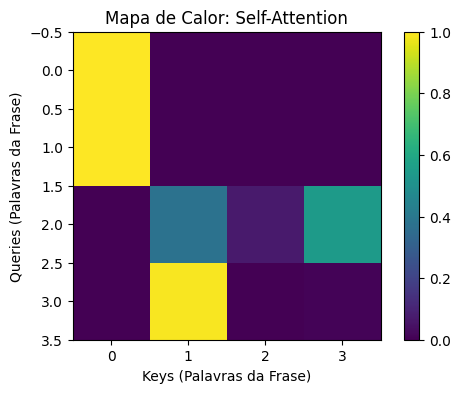

In [ ]:
# Multiplicação dos pesos pelos Valores
output = torch.matmul(attention_weights, V)

# Visualização da "Atenção"
plt.figure(figsize=(6, 4))
plt.imshow(attention_weights.detach().numpy(), cmap='viridis')
plt.colorbar()
plt.title("Mapa de Calor: Self-Attention")
plt.xlabel("Keys (Palavras da Frase)")
plt.ylabel("Queries (Palavras da Frase)")
plt.show()




### Sumarização Extrativa de Texto Usando Self-Attention

Vamos aplicar o conceito de self-attention para uma tarefa de Processamento de Linguagem Natural (PLN): a **sumarização extrativa de texto**. O objetivo é selecionar as frases mais importantes de um documento para formar um resumo.

Para simplificar, vamos:
1.  Dividir o texto em frases.
2.  Representar cada frase como um vetor (embedding). Para este exemplo, usaremos vetores aleatórios, mas em um cenário real, seriam embeddings de frases gerados por modelos como SBERT.
3.  Aplicar o mecanismo de self-attention para calcular as relações de atenção entre as frases.
4.  Usar os pesos de atenção para identificar e selecionar as frases mais relevantes para o resumo.

In [ ]:
#import torch                       #Biblioteca importada no bloco 1
#import torch.nn.functional as F    #Biblioteca importada no bloco 1
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt_tab')

# Baixar o tokenizador de frases do NLTK (se ainda não tiver)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError: # Corrigido para capturar LookupError
    nltk.download('punkt')

# 1. Exemplo de Texto Longo
long_text = (
    "A inteligência artificial (IA) é um campo vasto e em rápida evolução da ciência da computação. "
    "Ela visa criar máquinas capazes de realizar tarefas que normalmente exigiriam inteligência humana. "
    "Isso inclui aprendizado, raciocínio, resolução de problemas, percepção e compreensão da linguagem. "
    "A IA está transformando indústrias, desde a saúde até o transporte, com aplicações como carros autônomos e diagnósticos médicos assistidos por IA. "
    "Embora a IA ofereça um potencial tremendo, também levanta questões éticas e desafios importantes sobre seu impacto na sociedade. "
    "É essencial desenvolver a IA de forma responsável, considerando a privacidade, segurança e o futuro do trabalho. "
    "O aprendizado de máquina, um subconjunto da IA, foca em sistemas que aprendem com dados sem serem explicitamente programados. "
    "Redes neurais profundas, inspiradas no cérebro humano, impulsionam muitos dos avanços recentes em IA. "
    "A compreensão de modelos como o Transformer, que utiliza self-attention, é crucial para o desenvolvimento de sistemas de IA mais avançados e eficientes."
)

# 2. Dividir o texto em frases
sentences = sent_tokenize(long_text, language='portuguese')
num_sentences = len(sentences)

print(f"Número de frases no texto: {num_sentences}")
for i, sent in enumerate(sentences):
    print(f"Frase {i+1}: {sent}")

# 3. Simular embeddings de frases (em um cenário real, usaríamos um modelo de embeddings)
d_sentence_embed = 64  # Dimensão do embedding de cada frase

# Cada frase é um vetor de dimensão d_sentence_embed
x_sentences = torch.randn(num_sentences, d_sentence_embed)
print(f"\nShape dos embeddings de frases: {x_sentences.shape}")


Número de frases no texto: 9
Frase 1: A inteligência artificial (IA) é um campo vasto e em rápida evolução da ciência da computação.
Frase 2: Ela visa criar máquinas capazes de realizar tarefas que normalmente exigiriam inteligência humana.
Frase 3: Isso inclui aprendizado, raciocínio, resolução de problemas, percepção e compreensão da linguagem.
Frase 4: A IA está transformando indústrias, desde a saúde até o transporte, com aplicações como carros autônomos e diagnósticos médicos assistidos por IA.
Frase 5: Embora a IA ofereça um potencial tremendo, também levanta questões éticas e desafios importantes sobre seu impacto na sociedade.
Frase 6: É essencial desenvolver a IA de forma responsável, considerando a privacidade, segurança e o futuro do trabalho.
Frase 7: O aprendizado de máquina, um subconjunto da IA, foca em sistemas que aprendem com dados sem serem explicitamente programados.
Frase 8: Redes neurais profundas, inspiradas no cérebro humano, impulsionam muitos dos avanços recen

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# 4. Projeções Lineares (Q, K, V) para Sentenças
# Usamos uma dimensão d_k_sentences para as chaves/queries das frases
d_k_sentences = 32

# Inicialização das Matrizes de Pesos (Weights) para as frases
W_q_s = torch.randn(d_sentence_embed, d_k_sentences)
W_k_s = torch.randn(d_sentence_embed, d_k_sentences)
W_v_s = torch.randn(d_sentence_embed, d_k_sentences)

# Gerando Queries, Keys e Values via Produto Matricial para as frases
Q_sentences = torch.matmul(x_sentences, W_q_s)
K_sentences = torch.matmul(x_sentences, W_k_s)
V_sentences = torch.matmul(x_sentences, W_v_s)

print(f"Shape de Q_sentences, K_sentences e V_sentences: {Q_sentences.shape}")

# 5. O Cálculo da Afinidade (Scaled Dot-Product) para Sentenças
# Produto Escalar entre Q_sentences e K_sentences Transposto
scores_sentences = torch.matmul(Q_sentences, K_sentences.T)

# Escalonamento
scores_sentences = scores_sentences / (d_k_sentences ** 0.5)

# Softmax para obter os pesos de atenção entre as frases
attention_weights_sentences = F.softmax(scores_sentences, dim=-1)

print("\nMatriz de Atenção entre as Frases:")
print(attention_weights_sentences)


Shape de Q_sentences, K_sentences e V_sentences: torch.Size([9, 32])

Matriz de Atenção entre as Frases:
tensor([[0.0000e+00, 1.0000e+00, 1.6632e-20, 1.3184e-28, 4.3440e-44, 0.0000e+00,
         1.6334e-27, 2.8026e-45, 0.0000e+00],
        [2.2581e-08, 1.3319e-05, 2.1604e-01, 4.5777e-31, 0.0000e+00, 7.8307e-01,
         8.7979e-04, 1.4529e-34, 0.0000e+00],
        [1.0382e-13, 1.5628e-26, 5.5278e-20, 3.5548e-18, 2.4326e-22, 9.9947e-01,
         1.4279e-36, 5.2585e-04, 0.0000e+00],
        [4.5045e-14, 3.2440e-35, 0.0000e+00, 0.0000e+00, 1.0000e+00, 9.7483e-39,
         0.0000e+00, 0.0000e+00, 1.6837e-20],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 1.2070e-33, 0.0000e+00, 0.0000e+00,
         2.0135e-16, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.5414e-44, 0.0000e+00,
         0.0000e+00, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 6.9433e-21, 0.0000e+00,
         0.0000e+00, 2.4474e-09, 6.0532e-20],
      

In [ ]:
# 6. Sumarização Extrativa

# Para a sumarização, podemos usar os pesos de atenção para determinar a importância de cada frase.
# Uma abordagem simples é somar os pesos de atenção que uma frase recebe (coluna) ou atribui (linha).
# Aqui, vamos somar as linhas para ver o quanto cada frase 'presta atenção' no contexto geral.
# Ou podemos somar as colunas para ver o quanto cada frase é 'atendida' pelo resto do documento.

# Vamos usar a soma das linhas como um indicador de importância contextual.
sentence_importance = attention_weights_sentences.sum(dim=1)

# Podemos também considerar a soma dos pesos de atenção que cada frase recebe (soma por coluna)
# sentence_importance = attention_weights_sentences.sum(dim=0)

# Normalizar os scores de importância (opcional, mas pode ajudar na comparação)
sentence_importance = F.normalize(sentence_importance, p=1, dim=0)

print("\nScores de Importância de cada Frase:")
for i, score in enumerate(sentence_importance):
    print(f"Frase {i+1}: {score.item():.4f}")

# 7. Selecionar as N frases mais importantes para o resumo
num_summary_sentences = 3  # Número de frases para o resumo

# Obter os índices das frases mais importantes
# argsort retorna os índices que ordenariam o tensor
top_sentence_indices = torch.argsort(sentence_importance, descending=True)[:num_summary_sentences]

# Ordenar os índices para que o resumo mantenha a ordem original do texto
top_sentence_indices = sorted(top_sentence_indices.tolist())

print(f"\n### Resumo (Top {num_summary_sentences} frases):")
summary_sentences = [sentences[i] for i in top_sentence_indices]
for sent in summary_sentences:
    print(f"- {sent}")



Scores de Importância de cada Frase:
Frase 1: 0.1111
Frase 2: 0.1111
Frase 3: 0.1111
Frase 4: 0.1111
Frase 5: 0.1111
Frase 6: 0.1111
Frase 7: 0.1111
Frase 8: 0.1111
Frase 9: 0.1111

### Resumo (Top 3 frases):
- A inteligência artificial (IA) é um campo vasto e em rápida evolução da ciência da computação.
- A IA está transformando indústrias, desde a saúde até o transporte, com aplicações como carros autônomos e diagnósticos médicos assistidos por IA.
- Embora a IA ofereça um potencial tremendo, também levanta questões éticas e desafios importantes sobre seu impacto na sociedade.


In [ ]:
from sentence_transformers import SentenceTransformer

# 1. Carregar um modelo pré-treinado que gera embeddings contextualizados
# 'all-MiniLM-L6-v2' é um modelo pequeno e eficiente para embeddings de frases
# Para outros modelos, veja: https://www.sbert.net/docs/pretrained_models.html
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Definir as frases para as quais queremos embeddings
phrases = [
    "O banco da praça estava cheio de pessoas.",
    "Ele foi ao banco sacar dinheiro.",
    "SQL é uma linguagem para banco de dados."
]

# 3. Gerar os embeddings contextualizados
# O próprio modelo cuida da tokenização e da aplicação da arquitetura Transformer
# para gerar os embeddings de frase.
sentence_embeddings = model.encode(phrases)

# Exibir os resultados
print(f"Número de frases: {len(phrases)}")
print(f"Shape dos embeddings (Frases, Dimensão): {sentence_embeddings.shape}")
print("\nExemplo do embedding da primeira frase:")
print(sentence_embeddings[0][:10]) # Mostra os 10 primeiros valores do vetor

# Você pode então usar esses embeddings para calcular similaridade,
# clustering, ou como entrada para outras tarefas de ML/DL.

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Calcular a similaridade de cosseno entre as frases
similarities = cosine_similarity(sentence_embeddings)

print("\nMatriz de Similaridade de Cosseno:")
print(np.round(similarities, 3))

# Observe como as frases 2 e 3 ('banco sacar dinheiro', 'banco de dados')
# podem ter uma similaridade menor com a frase 1 ('banco da praça')
# e uma similaridade maior entre si no contexto de 'banco' como instituição financeira/conceito técnico.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Número de frases: 3
Shape dos embeddings (Frases, Dimensão): (3, 384)

Exemplo do embedding da primeira frase:
[ 0.00954795  0.03249394 -0.08590438 -0.02651985 -0.087096   -0.02466986
  0.05460094  0.11571469  0.04079948  0.04760642]

Matriz de Similaridade de Cosseno:
[[1.    0.629 0.577]
 [0.629 1.    0.443]
 [0.577 0.443 1.   ]]
